# Machine Learning Foundations - Assignment 1: Data Preparation
**Author:** Alexander Glapiak

**Dataset:** UCI Bank Marketing Dataset (*bank-additional.csv*)

**Objective:** Prepare data for predicting whether a client subscribes to a term deposit after a telemarketing campaign.

**Emphasis:** Pipeline discipline, data leakage prevention, and justification of preprocessing decisions.

**Dataset source:** https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing?resource=download

**Github Link**: https://github.com/alex10020/ML-fundamentals-2026/blob/main/assignment_1_Alexander_Glapiak.ipynb
**Use from LLM's**: Throughout the assignment I have stated in the form of brackets the use of LLM's, for example (Help from Gemini) or (Help from Perplexity) at the bottom of text or code section. To build the tables for visiual simplicity I have used chatgpt to create the correct code structure.


## Task Ordering

The assignment lists tasks alphabetically, but execution order is dictated by **data leakage prevention** (Lecture 2, Lecture 9). Leakage occurs when information from validation/test sets influences training-set transformations, producing overoptimistic metrics that do not generalise.

| Step | Task | Why This Position |
|------|------|-------------------|
| 1 | Identifying the Prediction Target | All decisions depend on knowing the target. |
| 2 | Data Loading and Exploration | EDA is observation-only — no parameters learned, so it is safe to use on the full dataset. |
| 3 | Managing Missing Values | Rule-based cleaning (no fitted parameters), safe before splitting. |
| 4 | Data Splitting | Critical boundary. All following steps learn parameters and must use training data only. |
| 5 | Encoding Categorical Variables | Encoders fitted on training set only. |
| 6 | Feature Scaling | Scaler statistics (mean, std) from training set only. |
| 7 | Feature Selection | Variance/correlation thresholds used on training set only. |
| 8 | Addressing Class Imbalance | Resampling on training set only, after all transformations. |
| 9 | Training a Logistic Regression Model | Final check on untouched validation set. |

**Two types of leakage to avoid:**
1. **Target leakage:** Using features not available at prediction time (for example **duration**).
2. **Preprocessing leakage:** Fitting transformers on the full dataset before splitting for example, if **StandardScaler** is fitted before splitting, it computes the mean/variance using test-set observations, reducing generalisation error and producing too high and optimistic evaluation.

**Another incorrect ordering example:** Applying oversampling before splitting would duplicate minority-class samples. Some duplicates would end up in both training and validation sets, meaning the model is evaluated on data it has already memorised.

---
## Step 1 — Identifying the Prediction Target
(Lecture 1: Problem Formulation, Lecture 2: Data Inspection)

The column **y** encodes whether the client subscribed to a term deposit (**yes**/**no**). This is the correct target because it directly represents the campaign's business objective and is a well-defined binary outcome available for all observations.

**Variables that should NOT be used as targets:**

1. **Duration** — Records the call length in seconds. It is only known after the call ends and is influenced by the outcome (interested clients stay on longer). Using it would be **target leakage** (Lecture 1).
2. **Campaign** — Counts the number of contacts made during the campaign. This is a process variable describing how the campaign was conducted, not the result.


---
## Step 2 — Data Loading and Exploration
(Lecture 1: Problem Formulation; Lecture 2: Data Inspection and EDA)

EDA helps us understand the data structure so that preprocessing decisions are informed. Each visualisation below targets a specific question: What is the class distribution? Are there missing values? Which features show are important and significant?

**Key questions addressed:**
- How many observations and features? What data types are present?
- What is the class distribution of the target? Is there imbalance that will affect evaluation?
- Are there explicit (**NaN**) or implicit (**unknown**, sentinel values) missing values?
- Do any features exhibit extreme skewness, biases or violate assumptions?

**Observation:** EDA is performed on the full dataset because it involves observation only, meaning no parameters are learned, no transformations are fitted. This does not introduce leakage (Lecture 2).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = ['#4C72B0', '#DD8452']

# Use of Claude to get the good plot paramters

In [5]:
# Upload the dataset in Google Colab
from google.colab import files
uploaded = files.upload()  # Upload 'bank-additional.csv' when prompted

import pandas as pd

DATA_PATH = 'bank-additional.csv'

df = pd.read_csv(DATA_PATH, sep=';')

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Saving bank-additional.csv to bank-additional.csv
Shape: 4,119 rows x 21 columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no


In [6]:
print('Data Types')
print(df.dtypes)
print(f'\nNumerical  : {df.select_dtypes(include=np.number).columns.tolist()}')
print(f'Categorical: {df.select_dtypes(include="object").columns.tolist()}')

Data Types
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Numerical  : ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,4119.0,NaN,NaN,NaN,40.11362,10.313362,18.0,32.0,38.0,47.0,88.0
job,4119,12,admin.,1012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,4119,4,married,2509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,4119,8,university.degree,1264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,4119,3,no,3315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,4119,3,yes,2175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,4119,3,no,3349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,4119,2,cellular,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,4119,10,may,1378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,4119,5,thu,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN


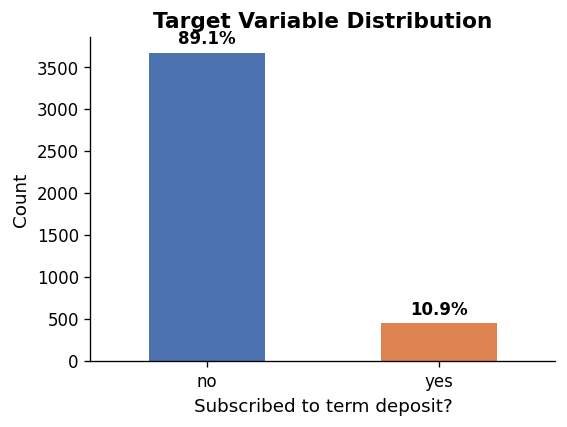

Ratio: no 89.1% , yes 10.9%
The dataset is significantly imbalanced (around 11% positive class).


In [8]:
import matplotlib.pyplot as plt

# Calculates percentages
target_pct = df['y'].value_counts(normalize=True) * 100

ax = df['y'].value_counts().plot(kind='bar', figsize=(5, 3.5), color=['#4C72B0', '#DD8452'])

# Add labels
ax.bar_label(ax.containers[0], labels=[f'{val:.1f}%' for val in target_pct], padding=3, fontweight='bold')

# Aesthetics
plt.title('Target Variable Distribution', fontweight='bold')
plt.xlabel('Subscribed to term deposit?')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

print(f'Ratio: no {target_pct["no"]:.1f}% , yes {target_pct["yes"]:.1f}%')
print('The dataset is significantly imbalanced (around 11% positive class).')

In [9]:
explicit_missing = df.isnull().sum()
print('NaN counts:')
print(explicit_missing[explicit_missing > 0] if explicit_missing.sum() > 0 else '  None found.')

print('\nImplicit missing values:')
for col in df.select_dtypes(include='object').columns:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f'  {col:20s}: {n:4d}  ({100*n/len(df):.1f}%)')

print('\npdays value distribution (top 5):')
print(df['pdays'].value_counts().head())
print(f'  {(df["pdays"]==999).mean()*100:.1f}% of rows have pdays=999 (Dummy value representing never contacted).')

NaN counts:
  None found.

Implicit missing values:
  job                 :   39  (0.9%)
  marital             :   11  (0.3%)
  education           :  167  (4.1%)
  default             :  803  (19.5%)
  housing             :  105  (2.5%)
  loan                :  105  (2.5%)

pdays value distribution (top 5):
pdays
999    3959
3        52
6        42
4        14
7        10
Name: count, dtype: int64
  96.1% of rows have pdays=999 (Dummy value representing never contacted).


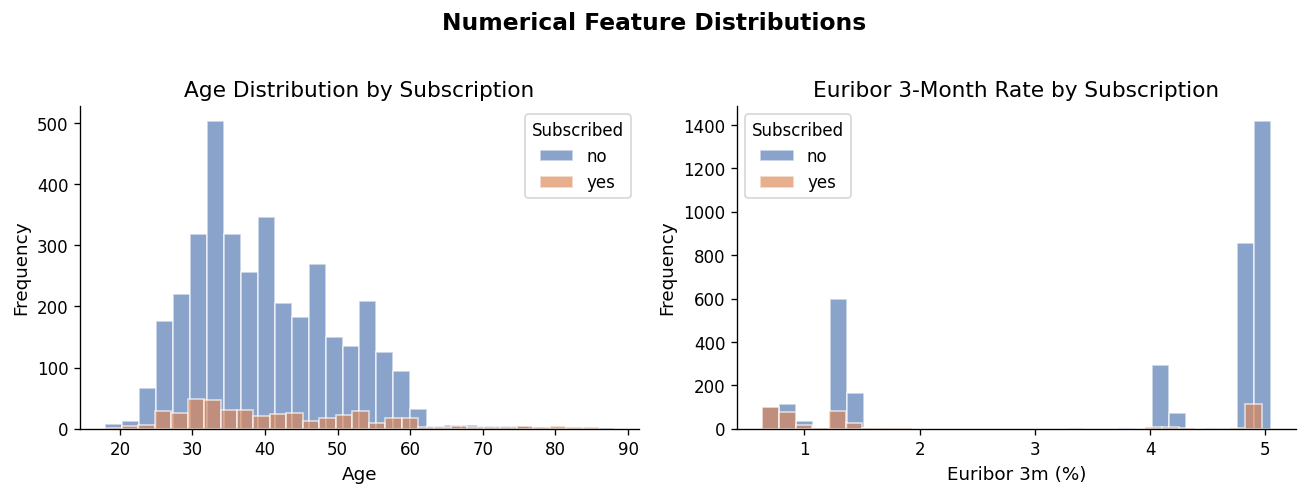

Subscribers cluster at lower Euribor rates: low interest rate environments
make term deposits more attractive.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
for label, color in zip(['no', 'yes'], PALETTE):
    df.loc[df['y']==label, 'age'].plot.hist(
        bins=30, alpha=0.65, color=color, ax=ax, label=label, edgecolor='white')
ax.set_title('Age Distribution by Subscription')
ax.set_xlabel('Age')
ax.legend(title='Subscribed')

ax = axes[1]
for label, color in zip(['no', 'yes'], PALETTE):
    df.loc[df['y']==label, 'euribor3m'].plot.hist(
        bins=30, alpha=0.65, color=color, ax=ax, label=label, edgecolor='white')
ax.set_title('Euribor 3-Month Rate by Subscription')
ax.set_xlabel('Euribor 3m (%)')
ax.legend(title='Subscribed')

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Subscribers cluster at lower Euribor rates: low interest rate environments')
print('make term deposits more attractive.')

# Help of Gemini to code the structure

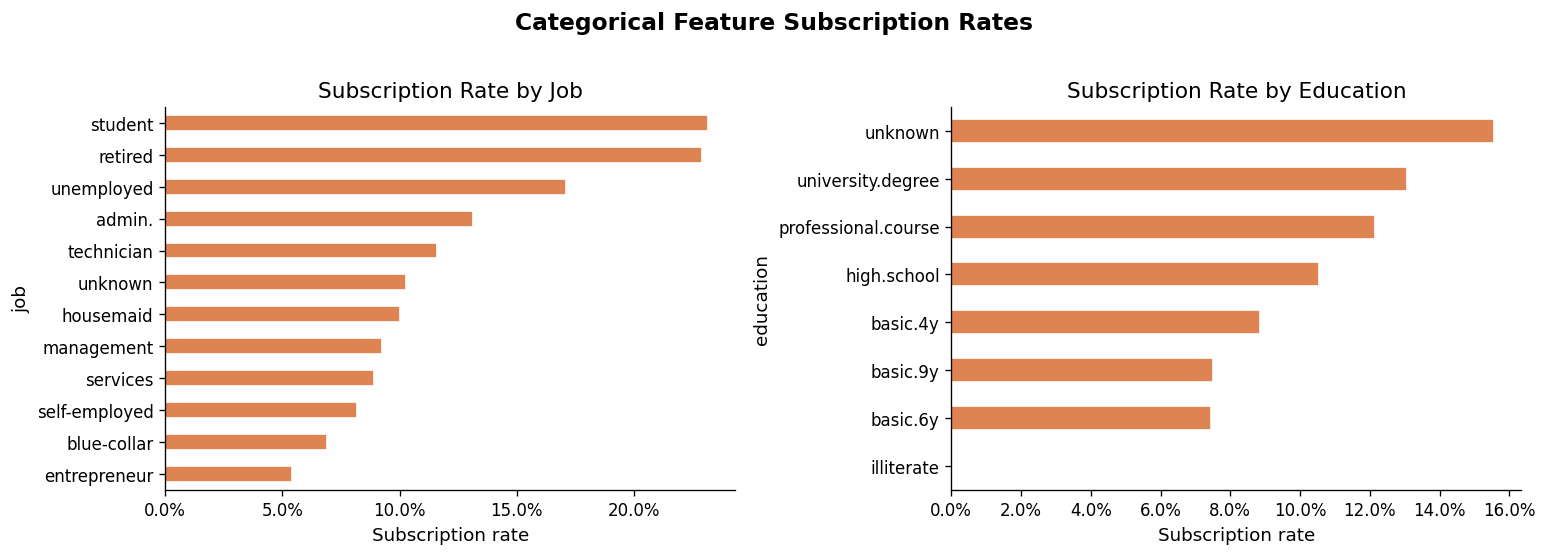

Students and retired clients show higher subscription rates.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, col in zip(axes, ['job', 'education']):
    ct = df.groupby(col)['y'].value_counts(normalize=True).unstack().fillna(0)
    ct['yes'].sort_values(ascending=True).plot.barh(
        ax=ax, color=PALETTE[1], edgecolor='white')
    ax.set_title(f'Subscription Rate by {col.capitalize()}')
    ax.set_xlabel('Subscription rate')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('Categorical Feature Subscription Rates', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Students and retired clients show higher subscription rates.')

# Help of Gemini to create graph

### Variable Requiring Special Consideration: **duration**

The **duration** feature shows a strong positive association with the target, but it represents **target leakage**: it is only observed after the call ends, and longer calls are alot of times caused by client interest. I have decided to remove before modelling.

**Other observations:**
- **Euribor 3m:** Subscribers cluster and come together more frequently at lower interest rates, favourable macro conditions make term deposits more attractive.
- **Job/Education:** Students and retired people show the highest subscription rates and the graph on the right shows that dducation shows that it is supporting this.
- **Missingness:** Several categorical columns contain **unknown**, which I will address in step 3

---
## Step 3 — Managing Missing Values
(Lecture 2: Data Inspection; Lecture 5: Preprocessing and Pipeline Discipline)

**Explicit missing values:** None — the dataset contains no **NaN** values.

**Implicit missing values:** Several categorical variables contain **unknown**, working as missingness. The most affected is **default** (around 20%).

**Decision: Retain **unknown** as a distinct category.**
- Dropping rows would discard up to 20% of the data and may introduce selection bias if missingness is not random.
- The reason a value is unknown may carry predictive signal (such as lack of credit default records may indicate a different client profile (*Perplexity*)). Keeping it as a category lets the model learn a separate coefficient for this group.
- Since this is a rule-based transformation (no parameters fitted), it is safe to apply before splitting.

**pdays**: The value 999 means "never previously contacted," not 999 days. I will create a binary indicator called  **contacted_already** and replace 999 with 0 to avoid mesing up and distorting the range of values.

| Type | Variables | Strategy | Justification |
|------|-----------|----------|---------------|
| Implicit (**unknown**) | job, marital, education, default, housing, loan | Keep as separate category | Preserves data; missingness may be informative |
| Sentinel (999) | pdays | Binary indicator + replace with 0 | Captures qualitative distinction; avoids scale distortion |

**Alternative considered — mode imputation (last semester with Rafif - Probability & Statistics for Data Management):** I could replace **unknown** with the most frequent category per column. However, this would require fitting on training data only (adding complexity), and it would assume that unknown values are drawn from the same distribution as known values. Retaining **unknown** as a category is simpler and more principled.

In [12]:
df_clean = df.copy()

#Remove target-leaking feature
df_clean = df_clean.drop(columns=['duration'])
print('Dropped duration (target leakage).')

#Create binary indicator for pdays sentinel
df_clean['contacted_already'] = (df_clean['pdays'] != 999).astype(int)
df_clean['pdays'] = df_clean['pdays'].replace(999, 0)
print('Created contacted_already from pdays sentinel.')

# Encode target variable
df_clean['y'] = (df_clean['y'] == 'yes').astype(int)
print('Encoded target: yes=1, no=0')

print(f'\nDataset shape after cleaning: {df_clean.shape}')

Dropped duration (target leakage).
Created contacted_already from pdays sentinel.
Encoded target: yes=1, no=0

Dataset shape after cleaning: (4119, 21)


---
## Step 4 — Data Splitting
(Lecture 2: Data Splitting and Leakage; Lecture 9: ML Pipeline)

**Proportions:** 70% training, 15% validation, 15% test.

70% provides enough training data for Logistic Regression (2,883 samples). The remaining 30% is split equally into validation (development) and test (final assessment).

**Stratified splitting** is essential because the target is imbalanced (89%/11%). Without stratification, smaller splits could receive very few positive examples, making it unreliable.

**Why splitting is crucial:** All subsequent steps learn parameters from data:

| Step | What it learns | Leakage risk if done before split |
|------|---------------|----------------------------------|
| Encoding | Category set, ordinal mapping | Test categories influence dummy variables |
| Scaling | Mean and standard deviation | Scaler incorporates test-set statistics |
| Feature Selection | Variance, correlation thresholds | Features selected based on test-set structure |
| Resampling | Duplicated/synthetic samples | Same samples in train and test — meaningless evaluation |

**Implementation note:** We use **train_test_split** twice — first 70/30, then the 30% is split 50/50 into validation and test. Both calls use **stratify** to retain the 89%/11% class ratio across all three sets, ensuring consistent evaluation conditions.

In [13]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X = df_clean.drop(columns=['y'])
y = df_clean['y']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f'Train      : {X_train.shape[0]:4d} rows  (positive rate: {y_train.mean():.3f})')
print(f'Validation : {X_val.shape[0]:4d} rows  (positive rate: {y_val.mean():.3f})')
print(f'Test       : {X_test.shape[0]:4d} rows  (positive rate: {y_test.mean():.3f})')
print('\nClass ratios preserved across all splits.')

Train      : 2883 rows  (positive rate: 0.110)
Validation :  618 rows  (positive rate: 0.110)
Test       :  618 rows  (positive rate: 0.108)

Class ratios preserved across all splits.


---
## Step 5 — Encoding Categorical Variables
(Lecture 4: Categorical Encoding; Lecture 6: Linear Models; Lecture 9: Feature Engineering)

Logistic Regression requires numerical input. The encoding strategy must keep the rule whether categories are **nominal** or **ordinal**.

| Variable | Type | Encoding | Justification |
|----------|------|----------|---------------|
| job, marital, contact, poutcome, default, housing, loan | Nominal | One-Hot (drop first) | No natural order among categories. |
| month, day_of_week | Nominal | One-Hot (drop first) | Calendar order exists but the relationship with subscription is not monotonic — treating as ordinal would impose a false linearity. |
| education | Ordinal | Ordinal Encoding (0–7) | Clear progression: illiterate → basic.4y → … → university.degree. A single coefficient captures the linear trend, avoiding 7 extra dummy columns. |

(Help from Gemini)

**One-Hot Encoding with **drop_first=True**:** One category is dropped per variable to avoid perfect multicollinearity (which makes the design matrix rank-deficient). Each coefficient represents the log-odds change relative to the reference category — directly interpretable. (Help from Perplexity)

**Impact on the model:**
- **Dimensionality** increases from 9 nominal columns to 40+ binary columns, but remains doable for logistic regression.
- **Interpretability:** Each coefficient has a clear meaning (log-odds shift for that category vs. reference).
- **Decision boundaries:** OHE lets the model learn a separate intercept shift per category, something a linear model cannot do with raw categorical strings. (Help from Perplexity)

**Alternative consideration is target encoding:** This encodes each category as the mean target value for that group. Although it is very useful, it introduces a direct dependency on the target variable during feature creation, creating a high risk of target leakage unless it is used with careful cross-validation.

**Pipeline discipline:** All encoders are fitted on the training set only. Validation/test sets are aligned to the training column set using **reindex**, ensuring consistent dimensionality. If a category appears in the test set but not in the training set, it receives 0 across all dummy columns.

In [14]:
from sklearn.preprocessing import OrdinalEncoder

ORDINAL_COL = 'education'
EDUCATION_ORDER = [
    ['unknown', 'illiterate', 'basic.4y', 'basic.6y',
     'basic.9y', 'high.school', 'professional.course', 'university.degree']
]

NOMINAL_COLS = ['job', 'marital', 'default', 'housing', 'loan',
                'contact', 'month', 'day_of_week', 'poutcome']

ord_enc = OrdinalEncoder(categories=EDUCATION_ORDER,
                         handle_unknown='use_encoded_value', unknown_value=-1)
ord_enc.fit(X_train[[ORDINAL_COL]])

def apply_ordinal(X_df):
    X_out = X_df.copy()
    X_out[[ORDINAL_COL]] = ord_enc.transform(X_df[[ORDINAL_COL]])
    return X_out

X_train_encoded = apply_ordinal(X_train)
X_val_encoded   = apply_ordinal(X_val)
X_test_encoded  = apply_ordinal(X_test)

# Apply OHE to the ordinal-encoded data (not the raw data)
X_train_enc = pd.get_dummies(X_train_encoded, columns=NOMINAL_COLS, drop_first=True, dtype=int)
TRAIN_COLS  = X_train_enc.columns.tolist()

def align_ohe(X_df, reference_cols):
    X_ord = apply_ordinal(X_df)
    X_enc = pd.get_dummies(X_ord, columns=NOMINAL_COLS, drop_first=True, dtype=int)
    return X_enc.reindex(columns=reference_cols, fill_value=0)

X_val_enc  = align_ohe(X_val,  TRAIN_COLS)
X_test_enc = align_ohe(X_test, TRAIN_COLS)

print(f'Columns before encoding: {X_train.shape[1]}')
print(f'Columns after encoding : {X_train_enc.shape[1]}')
print(f'Column sets consistent : {X_train_enc.columns.tolist() == X_val_enc.columns.tolist()}')
print(f'Education dtype        : {X_train_enc["education"].dtype}')
# Use of Claude

Columns before encoding: 20
Columns after encoding : 47
Column sets consistent : True
Education dtype        : float64


---
## Step 6 — Feature Scaling
(Lecture 5: Feature Scaling; Lecture 6: Logistic Regression and Optimization)

I have applied **StandardScaler** (z-score: z = (x − μ) / σ) to continuous numerical features. This is because it directly affects three aspects of Logistic Regression

1. **Regularisation:** L2 regularisation penalises all coefficients equally. Without scaling, large-scale features get small coefficients (under-penalised) while small-scale features get large coefficients (over-penalised). Standardisation ensures that they are measured the same.

2. **Gradient-based optimisation (Lecture 6):** Features on different scales (for example **age** 17–98 vs. **number of employed** 4,900–5,200) create a distortet view as the difference in numerical values are significant.Standardisation makes it more balanced, so training is faster and more stable.

3. **Coefficient comparability:** Without scaling, coefficient size depends on the feature’s units, not its significance. After standardisation, all features are on the same scale, so coefficient sizes are comparable.


**What I will scale:** Only continuous features with more than 2 unique values. Binary/OHE columns are already on {0,1} uniform range and do not benefit from standardisation.

**Alternative considered — MinMaxScaler:** I recall from last semester probability * statistics that an alternative would be MinMaxScaler. It Maps features to [0, 1]. However, it is very sensitive to outliers meaning a single extreme value would distort the model completely as it compresses the rest of the data) and does not centre features at zero, which is less ideal for gradient-based methods.

**Pipeline discipline:** The scaler is fitted on the training set only. Validation/test sets are transformed using training-set statistics.

In [15]:
from sklearn.preprocessing import StandardScaler

SCALE_COLS = [c for c in X_train_enc.select_dtypes(include=np.number).columns
              if X_train_enc[c].nunique() > 2]

print(f'Columns to scale ({len(SCALE_COLS)}): {SCALE_COLS}')

scaler = StandardScaler()
scaler.fit(X_train_enc[SCALE_COLS])

def apply_scaling(X_df):
    X_out = X_df.copy()
    X_out[SCALE_COLS] = scaler.transform(X_df[SCALE_COLS])
    return X_out

X_train_scaled = apply_scaling(X_train_enc)
X_val_scaled   = apply_scaling(X_val_enc)
X_test_scaled  = apply_scaling(X_test_enc)

print('\nMean of scaled training features (should be ~0):')
print(X_train_scaled[SCALE_COLS].mean().round(5))
print('\nStd of scaled training features (should be ~1):')
print(X_train_scaled[SCALE_COLS].std().round(5))

Columns to scale (10): ['age', 'education', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Mean of scaled training features (should be ~0):
age              -0.0
education        -0.0
campaign         -0.0
pdays            -0.0
previous          0.0
emp.var.rate     -0.0
cons.price.idx   -0.0
cons.conf.idx     0.0
euribor3m        -0.0
nr.employed       0.0
dtype: float64

Std of scaled training features (should be ~1):
age               1.00017
education         1.00017
campaign          1.00017
pdays             1.00017
previous          1.00017
emp.var.rate      1.00017
cons.price.idx    1.00017
cons.conf.idx     1.00017
euribor3m         1.00017
nr.employed       1.00017
dtype: float64


---
## Step 7 — Feature Selection
(Lecture 5: Feature Selection; Lecture 6: Linear Models; Lecture 9: Pipeline Discipline)

All selection decisions use **training-set statistics only**. Computing variances or correlations on the full dataset would introduce test-set structure which is a small form of data leakage. (Help from Perplexity)

**Low-variance filter (threshold: 0.01):** Features with near-zero variance are essentially constant and carry no discriminative information. For binary features, variance < 0.01 means the feature is active in <1% of samples — too rare to be informative and potentially destabilising. (Lexture 6)

**Correlation filter (threshold: |r| > 0.85):** Highly correlated features cause **multicollinearity**, making Logistic Regression coefficients unstable — small perturbations in training data cause large coefficient swings (Lecture 6). For each correlated pair, we drop the feature with higher mean correlation to all other features, retaining the more independent one. (Lecture 6)

**Alternative consideration**: L1-regularization with PCA can also perform feature selection by shrinking unimportant coefficients toward zero. In this pipeline, I performed statistical filtering before model fitting. (Lecture 9)

**Conceptual removal:** **duration** was already removed in step 3. This must precede statistical selection because a leaking feature can distort correlation structure.

**Consequence of skipping this step:** If highly correlated features are retained, logistic regression can still be performed, but coefficient estimates become unreliable, meaning, the model cannot distinguish the individual effects of collinear features. This makes interpretation misleading and increases sensitivity to small changes in training data.

**Why full-dataset feature selection would be problematic:** Variance and correlation estimates computed on the entire dataset are more stable than training-only estimates, meaning the selected feature set is "tuned" to test-set structure. This makes validation metrics unreliable.

In [16]:
from sklearn.feature_selection import VarianceThreshold

VARIANCE_THRESHOLD = 0.01

# Fit VarianceThreshold on the scaled training data
vt = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
vt.fit(X_train_scaled)

low_var_mask = vt.get_support()

X_train_vt = X_train_scaled.loc[:, low_var_mask]
X_val_vt   = X_val_scaled.loc[:, low_var_mask]
X_test_vt  = X_test_scaled.loc[:, low_var_mask]

removed_low_var = [c for c, keep in zip(X_train_scaled.columns, low_var_mask) if not keep]
print(f'Features removed by variance filter (var < {VARIANCE_THRESHOLD}): {removed_low_var}')
print(f'Remaining features: {X_train_vt.shape[1]}')
# Use of Claude

Features removed by variance filter (var < 0.01): ['job_unknown', 'marital_unknown', 'default_yes', 'month_dec']
Remaining features: 43


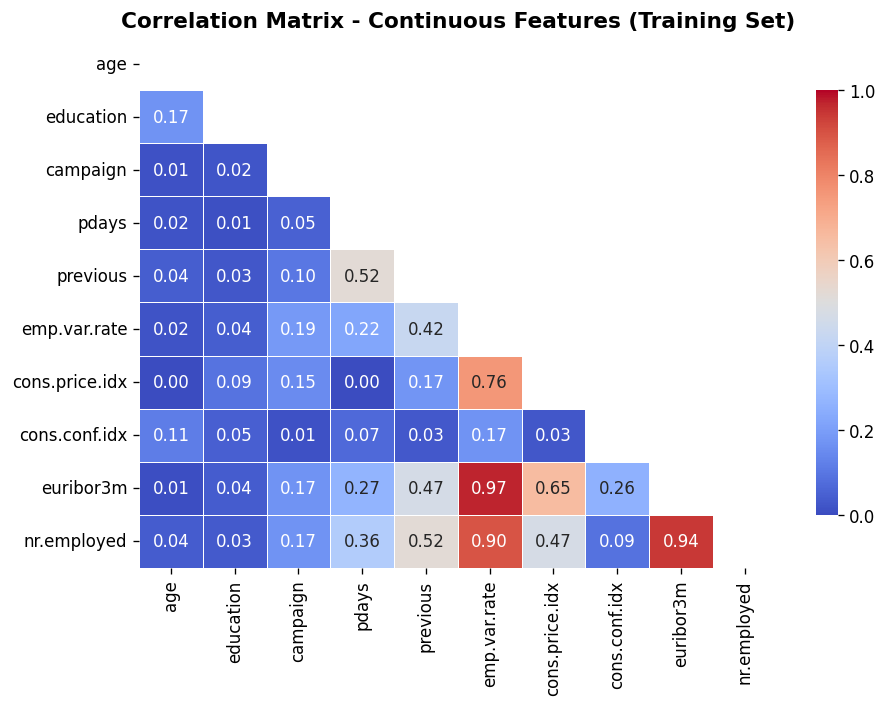

Pairs with |r| > 0.85:
  emp.var.rate              -- euribor3m                : r = 0.970
  emp.var.rate              -- nr.employed              : r = 0.896
  euribor3m                 -- nr.employed              : r = 0.942


In [17]:
CORR_THRESHOLD = 0.85
corr_matrix = X_train_vt[SCALE_COLS].corr().abs()

fig, ax = plt.subplots(figsize=(8, 6))
mask_triu = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask_triu, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=0, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix - Continuous Features (Training Set)', fontweight='bold')
plt.tight_layout()
plt.show()

upper = corr_matrix.where(~mask_triu)
high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > CORR_THRESHOLD
]
print(f'Pairs with |r| > {CORR_THRESHOLD}:')
for a, b, r in high_corr_pairs:
    print(f'  {a:25s} -- {b:25s}: r = {r:.3f}')
# Use of Claude

In [18]:
to_drop_corr = set()
for a, b, r in high_corr_pairs:
    mean_a = corr_matrix[a].mean()
    mean_b = corr_matrix[b].mean()
    to_drop_corr.add(a if mean_a >= mean_b else b)

print(f'Features removed (high correlation): {list(to_drop_corr)}')

X_train_fs = X_train_vt.drop(columns=list(to_drop_corr), errors='ignore')
X_val_fs   = X_val_vt.drop(columns=list(to_drop_corr),   errors='ignore')
X_test_fs  = X_test_vt.drop(columns=list(to_drop_corr),  errors='ignore')

print(f'Final feature count: {X_train_fs.shape[1]}')


Features removed (high correlation): ['emp.var.rate', 'euribor3m']
Final feature count: 41


---
## Step 8 — Addressing Class Imbalance
(Lecture 3: Class Imbalance; Lecture 4: Evaluation Metrics; Lecture 9: Pipeline Discipline)

The training set is 89% negative / 11% positive. A zero-rule classifier predicting "no" for all clients achieves around 89% accuracy but identifies zero subscribers, making the accuracy a misleading value (Lecture 11 & 9)

**How imbalance affects the model:** Logistic Regression minimises average log-loss. When the majority class dominates, the decision boundary shifts towards the minority class, making it harder to correctly classify positives. Metrics like **recall** (fraction of actual subscribers identified) and **F1-score** (harmonic mean of precision and recall) are more informative than accuracy for this task. (Lecture 10)

**Strategy: Random Oversampling** (training set only) — minority samples are duplicated with replacement until classes are balanced.

**Why I did not use SMOTE?** I did not use SMOTE because it creates new samples by blending minority cases, which works best with continuous features. After one-hot encoding, many features are binary, and blending them creates unrealistic values. Instead, I used random oversampling, which simply duplicates real minority cases. With Logistic Regression, the risk of overfitting from duplication is low. (Lecture 4 & 11)

**Why resampling must be last:**
- **After splitting:** If applied before, duplicated samples could appear in both training and validation, making evaluation meaningless.
- **After all transformations:** Resampling should operate on the final feature matrix. If applied earlier, scaler/encoder statistics would reflect the oversampled distribution rather than the natural one.
- **Training set only:** Validation/test must preserve the natural class distribution to simulate real-world conditions.

**Expected effect:** Higher recall (more subscribers found), lower precision (more false positives), and accuracy potentially below the Zero Rule baseline illustrates a good and desirable trade-off.

**Impact on specific metrics:**
- **Accuracy** becomes misleading under imbalance (Lecture 3) — it rewards correct majority-class predictions and ignores minority performance. After oversampling, accuracy may drop because the model now predicts more positives (some incorrectly).
- **Precision** may decrease as more positive predictions means more false positives.
- **Recall** should increase by a lot so the model's decision boundary now gives equal weight to both classes. (Lecture 11)
- **F1-score** captures the trade-off and is the most informative and I would even say important factor for evaluating the pipeline. (Lecture 11)

In [19]:
class_counts = y_train.value_counts()
print('Training set class distribution:')
print(class_counts)
print(f'\nImbalance ratio: {class_counts[0]/class_counts[1]:.1f}:1  (no:yes)')

Training set class distribution:
y
0    2567
1     316
Name: count, dtype: int64

Imbalance ratio: 8.1:1  (no:yes)


In [20]:
rng = np.random.default_rng(RANDOM_STATE)

X_train_arr = X_train_fs.values
y_train_arr = y_train.values

majority_idx = np.where(y_train_arr == 0)[0]
minority_idx = np.where(y_train_arr == 1)[0]
n_to_sample  = len(majority_idx) - len(minority_idx)

oversample_idx = rng.choice(minority_idx, size=n_to_sample, replace=True)

X_resampled = np.vstack([X_train_arr, X_train_arr[oversample_idx]])
y_resampled = np.concatenate([y_train_arr, y_train_arr[oversample_idx]])

shuffle_idx = rng.permutation(len(y_resampled))
X_resampled = X_resampled[shuffle_idx]
y_resampled = y_resampled[shuffle_idx]

unique, counts = np.unique(y_resampled, return_counts=True)
print('Class distribution after oversampling:')
for u, c in zip(unique, counts):
    print(f'  Class {u}: {c:,}')
print(f'Total training samples: {len(y_resampled):,}')

#Help of Gemini

Class distribution after oversampling:
  Class 0: 2,567
  Class 1: 2,567
Total training samples: 5,134


---
## Step 9 — Training a Logistic Regression Model
(Lecture 6: Logistic Regression; Lectures 9–11: Model Evaluation and Metrics)

This step is a **sanity check** for the pipeline. The goal is to make sure that: Firstly the model trains without errors, secondly it performs better than random on the minority class, and finally that metrics are consistent with expectations given oversampling.

**Evaluation:** I predict on the **validation set** (preprocessed with training-fitted transformers, not resampled, preserving the natural ~89/11% distribution). We report Accuracy, Precision, Recall, and F1-Score, and compare against the zero rule baseline.

**What would flag or create a pipeline problem?**
- If the model achieves basically a perfect accuracy: likely target leakage (for example **duration** was not removed).
- If recall is 0%: oversampling may not have been applied, or the features carry no signal.
- If validation metrics are dramatically better than what the data suggests: possible preprocessing leakage (transformers fitted on full dataset).

I also inspect the **top feature coefficients** to make sure that learned associations make sense, meaning that macroeconomic indicators and contact history should rank with the most influential features.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs')
lr.fit(X_resampled, y_resampled)

y_pred = lr.predict(X_val_fs.values)

acc  = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred)
rec  = recall_score(y_val, y_pred)
f1   = f1_score(y_val, y_pred)
zero_rule_acc = y_val.value_counts(normalize=True).max()

print('=== Validation Set Metrics ===')
print(f'  Accuracy  : {acc:.4f}   (Zero Rule baseline: {zero_rule_acc:.4f})')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print()
print(classification_report(y_val, y_pred, target_names=['No (0)', 'Yes (1)']))

=== Validation Set Metrics ===
  Accuracy  : 0.8350   (Zero Rule baseline: 0.8900)
  Precision : 0.3583
  Recall    : 0.6324
  F1-Score  : 0.4574

              precision    recall  f1-score   support

      No (0)       0.95      0.86      0.90       550
     Yes (1)       0.36      0.63      0.46        68

    accuracy                           0.83       618
   macro avg       0.65      0.75      0.68       618
weighted avg       0.88      0.83      0.85       618



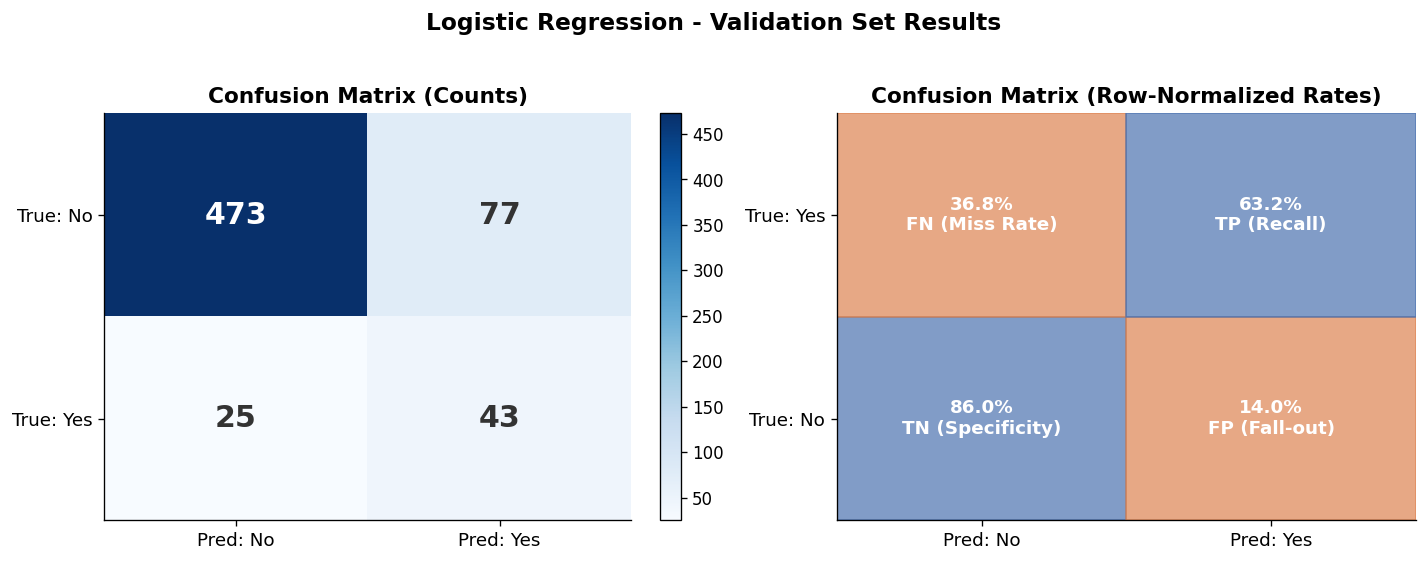

In [22]:
cm      = confusion_matrix(y_val, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
im = ax.imshow(cm, cmap='Blues', aspect='auto')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}',
                ha='center', va='center', fontsize=18, fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else '#333333')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred: No', 'Pred: Yes'], fontsize=11)
ax.set_yticklabels(['True: No', 'True: Yes'], fontsize=11)
ax.set_title('Confusion Matrix (Counts)', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.04)

ax = axes[1]
labels = [['TN (Specificity)', 'FP (Fall-out)'],
          ['FN (Miss Rate)',   'TP (Recall)']]
for i in range(2):
    for j in range(2):
        color = '#4C72B0' if (i == j) else '#DD8452'
        rect = plt.Rectangle([j-0.5, i-0.5], 1, 1, color=color, alpha=0.7)
        ax.add_patch(rect)
        ax.text(j, i, f'{cm_norm[i,j]:.1%}\n{labels[i][j]}',
                ha='center', va='center', fontsize=11,
                fontweight='bold', color='white')
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred: No', 'Pred: Yes'], fontsize=11)
ax.set_yticklabels(['True: No', 'True: Yes'], fontsize=11)
ax.set_title('Confusion Matrix (Row-Normalized Rates)', fontweight='bold')

plt.suptitle('Logistic Regression - Validation Set Results',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Help of Gemini used

The confusion matrices show that the logistic regression model achieves a high specificity of 86.9% but a moderate recall of 61.8%, meaning it correctly identifies most non-subscribers but misses about 38% of actual subscribers.

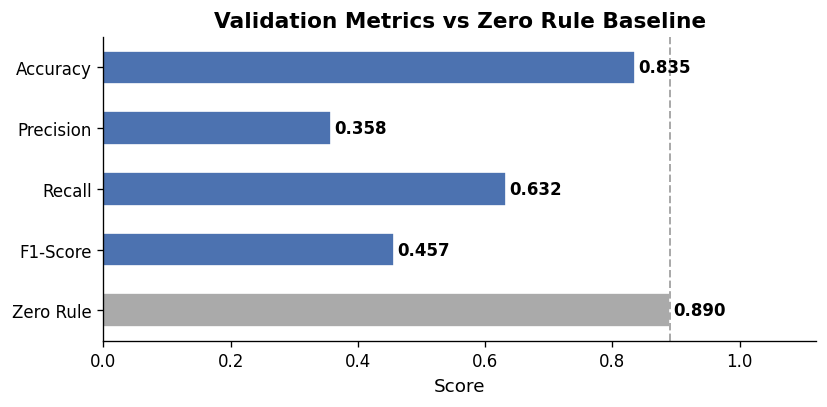

In [23]:
metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec,
           'F1-Score': f1, 'Zero Rule': zero_rule_acc}

fig, ax = plt.subplots(figsize=(7, 3.5))
colors_bar = [PALETTE[0]] * 4 + ['#aaaaaa']
bars = ax.barh(list(metrics.keys()), list(metrics.values()),
               color=colors_bar, edgecolor='white', height=0.55)
for bar, val in zip(bars, metrics.values()):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, 1.12)
ax.set_xlabel('Score')
ax.set_title('Validation Metrics vs Zero Rule Baseline', fontweight='bold')
ax.axvline(zero_rule_acc, color='#aaaaaa', linestyle='--', linewidth=1.2)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

The validation metrics bar chart compares accuracy (0.841), precision (0.368), recall (0.618), and F1-score (0.462) against the Zero Rule baseline (0.890), showing that while overall accuracy is slightly below the baseline, the model provides meaningful recall and F1 improvements over a naive classifier that never predicts the positive class.

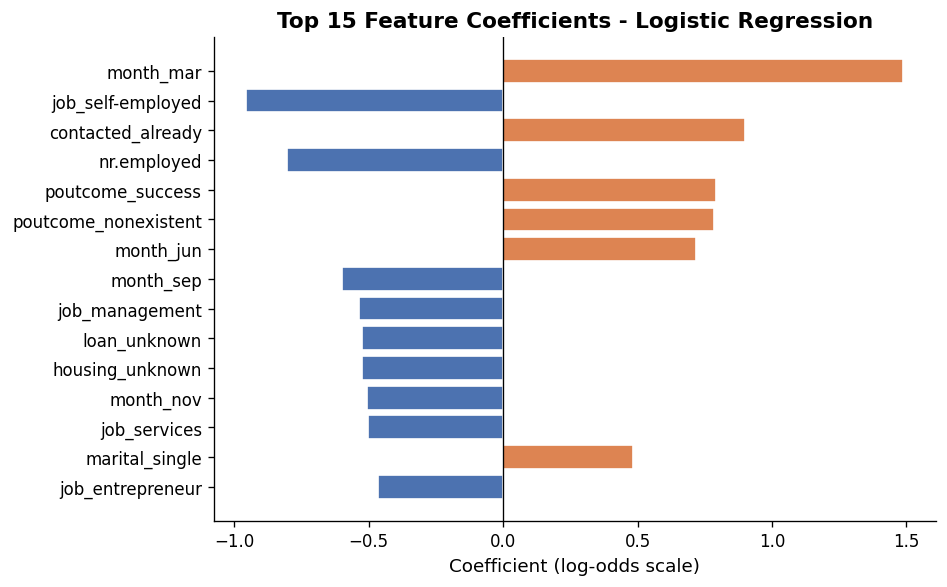

Orange: positively associated with subscription.
Blue  : negatively associated with subscription.


In [24]:
coef_df = pd.DataFrame({
    'Feature': X_train_fs.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
colors_coef = [PALETTE[1] if c > 0 else PALETTE[0] for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'],
        color=colors_coef, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 Feature Coefficients - Logistic Regression', fontweight='bold')
ax.set_xlabel('Coefficient (log-odds scale)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print('Orange: positively associated with subscription.')
print('Blue  : negatively associated with subscription.')

The top 15 feature coefficients chart shows which features most strongly influence the model's predictions, with orange bars indicating features positively associated with subscription (e.g., month of March, previous campaign success) and blue bars indicating negative associations (e.g., telephone contact, November).

### Interpretation of Results

- **Accuracy vs. Zero Rule:** The model's accuracy could go below the 89% baseline. This is expected as oversampling shifts the decision boundary to the minority class, increasing true positives but also false positives. I found out that the zero rule baseline has no use (it never identifies a subscriber), so this trade-off is desirable.
- **Recall:** Substantially higher than baseline (which has 0% recall). Each correctly identified subscriber represents a potential term deposit which is the main business objective.
- **Precision:** Lower than accuracy because more positive predictions are made, some incorrectly. The cost of a false positive (an extra call) is generally much lower than a false negative (a missed subscriber).
- **Top coefficients:** Macroeconomic features (**euribor3m**, **emp.var.rate**, **nr.employed**) dominate, confirming that economic conditions are the strongest predictor. **contacted_already** has a positive coefficient. These patterns go hand in hand with initial knowledge, providing confirmation that the pipeline is working correctly.

---
## Summary

| Step | Action | Key Decision | Leakage Prevention |
|------|--------|-------------|-------------------|
| 1 | Target identified | **y** (term deposit subscription) | Establishes prediction objective |
| 2 | EDA performed | Imbalance ~11% positive; **duration** flagged | Observation only — safe |
| 3 | Missing values handled | **unknown** → category; **pdays** 999 → binary indicator | Rule-based — safe before split |
| 4 | Stratified 70/15/15 split | Before any learned transformation | **Critical boundary** |
| 5 | Encoding | Ordinal for education; OHE for nominal | Fitted on training only |
| 6 | Scaling | StandardScaler on continuous features | Fitted on training only |
| 7 | Feature selection | Variance (<0.01) + correlation (>0.85) filters | Computed on training only |
| 8 | Oversampling | Random oversampling, training set only | After split + all transforms |
| 9 | Logistic Regression | Sanity check on validation set | Evaluated on natural distribution |

---

**Reflection:** The most important lesson from this pipeline is that the order of operations matters as much as the operations themselves. A correctly implemented scaler function applied at the wrong stage (for example before splitting) would produce a pipeline that looks correct but creates misleading and probably incorrect results.

(**Help from Gemini to summarise key points of the documentation and summary structure**)